In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("data/LoanEligibilityPrediction.csv")

In [4]:
df.describe()

,Customer_ID,Dependents,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000,614.000000
mean,307.500000,0.856678,5403.459283,1621.245798,142.022801,338.892508,0.850163
std,177.390811,1.216651,6109.041673,2926.248369,87.083089,69.716355,0.357203
min,1.000000,0.000000,150.000000,0.000000,9.000000,12.000000,0.000000
25%,154.250000,0.000000,2877.500000,0.000000,98.000000,360.000000,1.000000
50%,307.500000,0.000000,3812.500000,1188.500000,125.000000,360.000000,1.000000
75%,460.750000,2.000000,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,614.000000,4.000000,81000.000000,41667.000000,700.000000,480.000000,1.000000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Customer_ID         614 non-null    int64  
 1   Gender              614 non-null    object 
 2   Married             614 non-null    object 
 3   Dependents          614 non-null    int64  
 4   Education           614 non-null    object 
 5   Self_Employed       614 non-null    object 
 6   Applicant_Income    614 non-null    int64  
 7   Coapplicant_Income  614 non-null    float64
 8   Loan_Amount         614 non-null    int64  
 9   Loan_Amount_Term    614 non-null    int64  
 10  Credit_History      614 non-null    int64  
 11  Property_Area       614 non-null    object 
 12  Loan_Status         614 non-null    object 
dtypes: float64(1), int64(6), object(6)
memory usage: 62.5+ KB


In [6]:
df.head()

,Customer_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N
1,15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y
2,95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y
3,134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y
4,556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y


In [7]:
df.head().T

,0,1,2,3,4
Customer_ID,569,15,95,134,556
Gender,Female,Male,Male,Male,Male
Married,No,Yes,No,Yes,Yes
Dependents,0,2,0,0,1
Education,Graduate,Graduate,Not Graduate,Graduate,Graduate
Self_Employed,No,No,No,Yes,No
Applicant_Income,2378,1299,3620,3459,5468
Coapplicant_Income,0.0,1086.0,0.0,0.0,1032.0
Loan_Amount,9,17,25,25,26
Loan_Amount_Term,360,120,120,120,360


In [8]:
missing = pd.concat([df.isnull().sum(), 100 * df.isnull().mean()], axis=1)
missing.columns=['count', '%']
missing.sort_values(by='count')

,count,%
Customer_ID,0,0.0
Gender,0,0.0
Married,0,0.0
Dependents,0,0.0
Education,0,0.0
Self_Employed,0,0.0
Applicant_Income,0,0.0
Coapplicant_Income,0,0.0
Loan_Amount,0,0.0
Loan_Amount_Term,0,0.0


In [9]:
df.select_dtypes(include=object)

,Gender,Married,Education,Self_Employed,Property_Area,Loan_Status
0,Female,No,Graduate,No,Urban,N
1,Male,Yes,Graduate,No,Urban,Y
2,Male,No,Not Graduate,No,Semiurban,Y
3,Male,Yes,Graduate,Yes,Semiurban,Y
4,Male,Yes,Graduate,No,Semiurban,Y
...,...,...,...,...,...,...
609,Male,Yes,Graduate,No,Urban,N
610,Male,No,Graduate,No,Semiurban,N
611,Male,Yes,Graduate,Yes,Rural,N
612,Male,Yes,Not Graduate,No,Rural,Y


In [10]:
print(df['Gender'].unique())
print(df['Married'].unique())
print(df['Education'].unique())
print(df['Self_Employed'].unique())
print(df['Property_Area'].unique())
print(df['Loan_Status'].unique())

['Female' 'Male']
['No' 'Yes']
['Graduate' 'Not Graduate']
['No' 'Yes']
['Urban' 'Semiurban' 'Rural']
['N' 'Y']


In [11]:
df['Customer_ID'].is_unique

True

In [12]:
#set customer_id as index
df.set_index('Customer_ID', inplace=True)

In [22]:
#add applicant_coapplicant_income
df['Total_Income'] = df['Applicant_Income'] + df['Coapplicant_Income']

In [23]:
df.head()

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Applicant_Coapplicant_Income,Total_Income
Customer_ID,,,,,,,,,,,,,,
569,Female,No,0,Graduate,No,2378,0.0,9,360,1,Urban,N,2378.0,2378.0
15,Male,Yes,2,Graduate,No,1299,1086.0,17,120,1,Urban,Y,2385.0,2385.0
95,Male,No,0,Not Graduate,No,3620,0.0,25,120,1,Semiurban,Y,3620.0,3620.0
134,Male,Yes,0,Graduate,Yes,3459,0.0,25,120,1,Semiurban,Y,3459.0,3459.0
556,Male,Yes,1,Graduate,No,5468,1032.0,26,360,1,Semiurban,Y,6500.0,6500.0


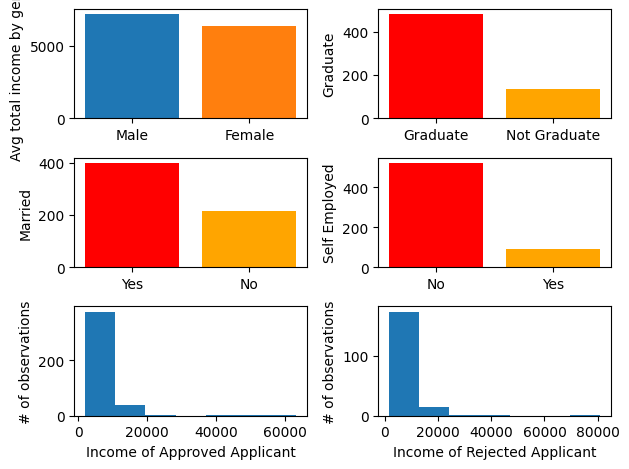

In [25]:
#just some data exploration

#sns.countplot(x=df['Gender']) #getting errors with my seaborn package

female_df = df[df['Gender'] == 'Female']
male_df = df[df['Gender'] == 'Male']
approved_df = df[df['Loan_Status'] == 'Y']
rejected_df = df[df['Loan_Status'] == 'N']

#Income
fig, ax = plt.subplots(3, 2)
ax[0, 0].bar("Male", male_df["Total_Income"].mean())
ax[0, 0].bar("Female", female_df["Total_Income"].mean())
ax[0, 0].set_ylabel("Avg total income by gender")

#Education
educ_count = df['Education'].value_counts()
educ_cat = educ_count.index
educ_val = educ_count.values

ax[0, 1].bar(educ_cat, educ_val, color=['red', 'orange'])
ax[0, 1].set_ylabel("Graduate")

#Married
married_count = df['Married'].value_counts()
married_cat = married_count.index
married_val = married_count.values

ax[1, 0].bar(married_cat, married_val, color=['red', 'orange'])
ax[1, 0].set_ylabel("Married")

#Self Employed
selfemp_count = df['Self_Employed'].value_counts()
selfemp_cat = selfemp_count.index
selfemp_val = selfemp_count.values

ax[1, 1].bar(selfemp_cat, selfemp_val, color=['red', 'orange'])
ax[1, 1].set_ylabel("Self Employed")

#Income for approved
ax[2, 0].hist(approved_df['Total_Income'], bins=7)
ax[2, 0].set_xlabel("Income of Approved Applicant")
ax[2, 0].set_ylabel("# of observations")

#Income for approved
ax[2, 1].hist(rejected_df['Total_Income'], bins=7)
ax[2, 1].set_xlabel("Income of Rejected Applicant")
ax[2, 1].set_ylabel("# of observations")

plt.tight_layout()
plt.show()

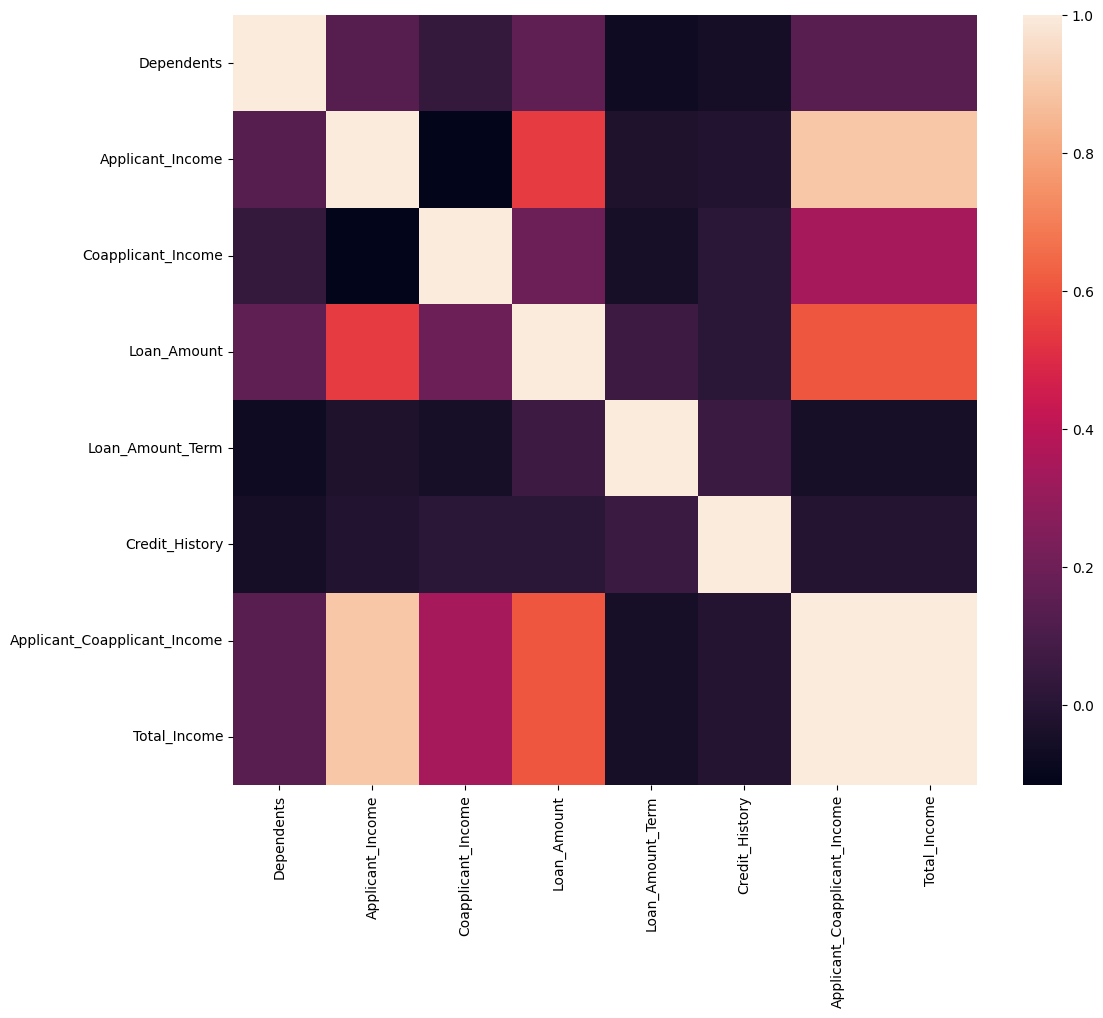

In [26]:
#update packages to use sns
#!pip install --upgrade pandas numpy matplotlib seaborn scipy
plt.subplots(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True));

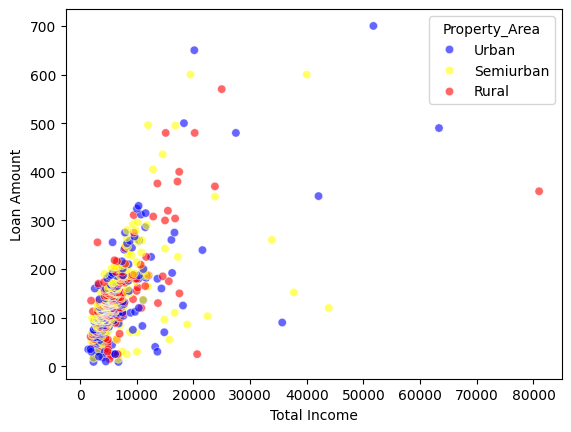

In [27]:
#update packages to use sns
#!pip install --upgrade pandas numpy matplotlib seaborn scipy
#plt.subplots(figsize=(12,10))
#sns.heatmap(df.corr(numeric_only=True));
sns.scatterplot(x=df["Total_Income"], y=df["Loan_Amount"], alpha=0.6, hue=df["Property_Area"], palette={"Urban": "blue", "Rural": "red", "Semiurban": "yellow"})
plt.xlabel("Total Income")
plt.ylabel("Loan Amount")
plt.show()